In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#load tennis data 
#function return outcome of nature and expert prediction
def load_tennis1(path="tennis1.txt"):    
    path="tennis1.txt"
    data = np.loadtxt(path)
    T = data.shape[0]
    omega = np.ones(T, dtype=float)              
    experts = data[:, [3,5,7,9]].T               
    return omega, experts
    

In [3]:
# omega, experts = load_tennis1()
# print('omega',omega[:5])
# experts[:, :5]

In [4]:
# this is
# 
# checnk if omega change id remain onlways one. in tghe  
def check_inequality(g0, g1, gamma, t, tol=1e-12):
    lambda0 = gamma**2
    lambda1 = (1 - gamma)**2

    ok0 = lambda0 <= g0 + tol
    ok1 = lambda1 <= g1 + tol

    if ok0 and ok1:
        print(f"At time {t}, inequality holds: "
              f"lambda(0)={lambda0:.4f} <= g(0)={g0:.4f} and "
              f"lambda(1)={lambda1:.4f} <= g(1)={g1:.4f}")
    else:

        print('NO HOLD')
        breakpoint


In [5]:
def AA_Brier(expertsPredictions,outcomes):
    # AA(expertsPredictions,outcomes) calculates predictions
    # produced by the AA given expertsPredictions (this is a
    # matrix whose lines are sequences of predictions) and
    # outcomes

    
    E = np.asanyarray(expertsPredictions, dtype=float)
    omega = np.asarray(outcomes, dtype=float) 
    N,T=E.shape
    eta=2.0

    #initialise weight to equal for all experts
    w = np.full(N,1.0/N,dtype=float)
    gammas = np.zeros(T,dtype=float)

    for t in range(T):
        #normalize weigghts
        w_sum=w.sum()
        # if w_sum == 0:
        #       raise ValueError("cannot normalize.")
        p=w/w_sum

        #experrts prediction at time t
        gexp=E[:,t]
        
        #compute g(0) and g(1)
        g0=-(1/eta)*np.log(np.sum(p*np.exp(-eta*(gexp**2))))
        g1=-(1/eta)* np.log(np.sum(p*np.exp(-eta*((1-gexp)**2))))

        # save g(0) and g(1) for checking the inequality
        g = np.array([g0, g1])
    
        #compute gamma
        gamma=0.5-((g1-g0)/2.0)
        gammas[t]=gamma

        #call checkinquality function to check the inequality between g(0), g(1) and the loss of AA
        #check_inequality(g0, g1, gamma, t)
        #update weights
        #print(w)
        w *= np.exp(-eta*((gexp-omega[t])**2))
        # update weights


        #keep weights from collapsing to 0
        w = w / np.sum(w)
        #print(w)
    #print("Final weights:", w)
    return gammas

In [6]:
##square loss
def square_loss(pred, outcome):
    return (outcome - pred) ** 2

In [7]:
#this computes cumulative losses for both experts and AA
def cumulative_losses(expertsPredictions, omega, gammas):
    # expert losses
    expert_losses = square_loss(expertsPredictions, omega.reshape(1, -1))
    # AA losses
    aa_losses = square_loss(gammas, omega)

    cum_expert = np.cumsum(expert_losses, axis=1)  
    cum_aa = np.cumsum(aa_losses)                  
    return cum_expert, cum_aa

In [8]:
#this computes cumulative average loss for thr experts.
def cumulative_avg_loss(expertsPredictions, omega):
    gamma_avg = np.mean(expertsPredictions, axis=0)   
    avg_losses = square_loss(gamma_avg, omega)        
    return np.cumsum(avg_losses)    

In [9]:
#this plots cumulative losses for both experts and AA
def plot_cumulative_losses(cum_expert, cum_aa):
    T = cum_aa.shape[0]
    t = np.arange(1, T + 1)

    plt.figure()
    for i in range(cum_expert.shape[0]):
        plt.plot(t, cum_expert[i], label=f"Loss_E{i+1}(t)")
    plt.plot(t, cum_aa, label="Loss_AA(t)")  
    plt.xlabel("t")
    plt.ylabel("Cumulative loss")
    plt.title("Cumulative losses vs time")
    plt.legend()
    plt.show()

In [10]:
#plot expert minus aa
def plot_experts_minus_aa(cum_expert, cum_aa):
    T = cum_aa.shape[0]
    t = np.arange(1, T + 1)

    plt.figure()
    for i in range(cum_expert.shape[0]):
        plt.plot(t, cum_expert[i] - cum_aa, label=f"Loss_E{i+1}(t) - Loss_AA(t)")
    plt.xlabel("t")
    plt.ylabel("Difference in cumulative loss")
    plt.title("Experts vs AA (cumulative loss differences)")
    plt.legend()
    plt.show()

In [11]:
#plot average of expert minus each experrt.
def plot_avg_minus_experts(cum_avg, cum_expert):
    T = cum_avg.shape[0]
    t = np.arange(1, T + 1)

    plt.figure()
    for i in range(cum_expert.shape[0]):
        plt.plot(t, cum_avg - cum_expert[i], label=f"Loss_avg(t) - Loss_E{i+1}(t)")
    plt.xlabel("t")
    plt.ylabel("Difference in cumulative loss")
    plt.title("Simple averaging vs experts")
    plt.legend()
    plt.show()


Total AA loss: 1972.338412390538


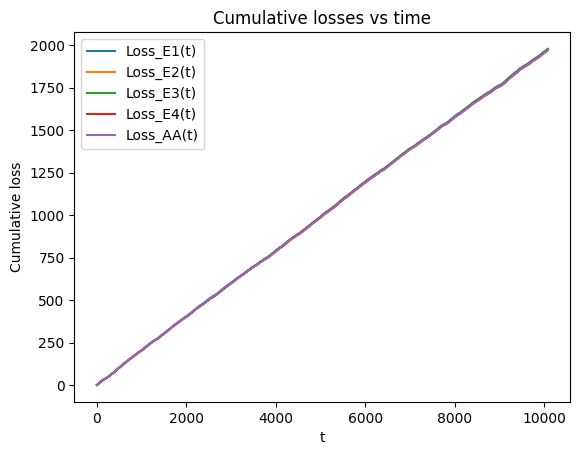

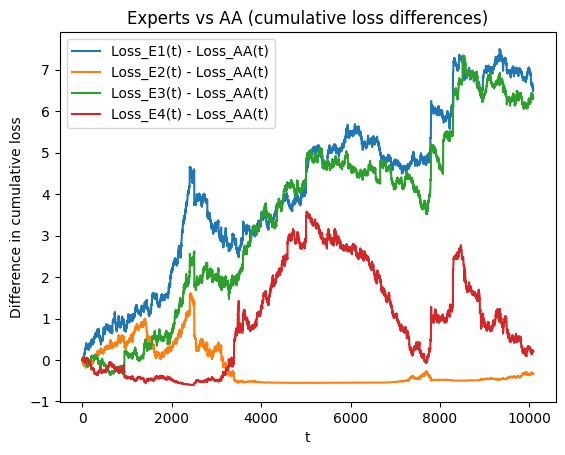

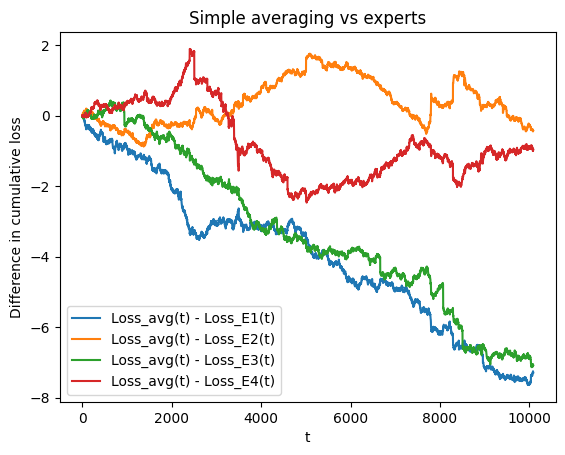

In [12]:
def run_all(path="tennis1.txt"):
    omega, expertsPredictions = load_tennis1(path)   

    # AA_Brier must already be defined in your notebook
    gammas = AA_Brier(expertsPredictions, omega)
    
    # print("Max difference between AA and Expert 3:",
    # np.max(np.abs(gammas - expertsPredictions[2])))

    cum_expert, cum_aa = cumulative_losses(expertsPredictions, omega, gammas)
    cum_avg = cumulative_avg_loss(expertsPredictions, omega)

    #total losses.
    print("Total AA loss:", cum_aa[-1])

    plot_cumulative_losses(cum_expert, cum_aa)     # Graph 1
    plot_experts_minus_aa(cum_expert, cum_aa)      # Graph 2
    plot_avg_minus_experts(cum_avg, cum_expert)    # Graph 3


run_all("tennis1.txt")